In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
villes = pd.read_csv("../data/villes_france_lat_long.csv")

villes.head()

,Ville,Latitude,Longitude
0,Paris,48.8566,2.3522
1,Marseille,43.2965,5.3698
2,Lyon,45.7640,4.8357
3,Toulouse,43.6047,1.4442
4,Nice,43.7102,7.2620


In [43]:
villes

,Ville,Latitude,Longitude
0,Paris,48.8566,2.3522
1,Marseille,43.2965,5.3698
2,Lyon,45.7640,4.8357
3,Toulouse,43.6047,1.4442
4,Nice,43.7102,7.2620
5,Nantes,47.2184,-1.5536
6,Strasbourg,48.5734,7.7521
7,Montpellier,43.6119,3.8772
8,Bordeaux,44.8378,-0.5792
9,Lille,50.6292,3.0573


In [44]:
from math import radians, sin, cos, sqrt, atan2


def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Rayon de la Terre en kilomètres

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1)
        * cos(lat2)
        * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))   # c= 2⋅atan2(√a​,√1−a​) Ce qui est équivalent à : c= 2⋅arcsin(√a​)

    return R * c

In [45]:
n = len(villes)

matrice_distances = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        if i != j:

            distance = haversine(
                villes.iloc[i]["Latitude"],
                villes.iloc[i]["Longitude"],
                villes.iloc[j]["Latitude"],
                villes.iloc[j]["Longitude"]
            )

            matrice_distances[i][j] = distance

In [46]:
matrice_distances

array([[  0.        , 660.47837967, 391.49893167, 588.13390402,
        685.10765029, 342.7339472 , 397.33930436, 594.82794824,
        499.29762496, 203.50916991, 308.13084834, 130.27206788,
        177.88374112, 409.88634156, 694.49982244, 481.24652632,
        262.68195941, 264.98404841, 579.0162233 , 346.86023334],
       [660.47837967,   0.        , 277.61875794, 318.70694559,
        159.39047065, 695.12804804, 614.92296034, 125.47986504,
        505.10982326, 833.9172087 , 765.44369106, 670.82050946,
        798.15563581, 250.78034221,  49.12828293, 212.26906265,
        448.34960566, 656.06105612, 101.12237944, 329.85362831],
       [391.49893167, 277.61875794,   0.        , 359.85831314,
        298.09982814, 514.98750616, 382.28743175, 251.00709475,
        435.76061648, 556.76757835, 559.20397989, 393.20615234,
        545.28623988,  50.17743875, 306.06394642,  94.32578679,
        173.95505047, 454.12021183, 217.56526525, 135.63811168],
       [588.13390402, 318.70694559, 3

In [47]:
matrice_df = pd.DataFrame(
    matrice_distances,
    index=villes["Ville"],
    columns=villes["Ville"]
)

matrice_df

Ville,Paris,Marseille,Lyon,Toulouse,Nice,Nantes,Strasbourg,Montpellier,Bordeaux,Lille,Rennes,Reims,Le Havre,Saint-Étienne,Toulon,Grenoble,Dijon,Angers,Nîmes,Clermont-Ferrand
Ville,,,,,,,,,,,,,,,,,,,,
Paris,0.000000,660.478380,391.498932,588.133904,685.107650,342.733947,397.339304,594.827948,499.297625,203.509170,308.130848,130.272068,177.883741,409.886342,694.499822,481.246526,262.681959,264.984048,579.016223,346.860233
Marseille,660.478380,0.000000,277.618758,318.706946,159.390471,695.128048,614.922960,125.479865,505.109823,833.917209,765.443691,670.820509,798.155636,250.780342,49.128283,212.269063,448.349606,656.061056,101.122379,329.853628
Lyon,391.498932,277.618758,0.000000,359.858313,298.099828,514.987506,382.287432,251.007095,435.760616,556.767578,559.203980,393.206152,545.286240,50.177439,306.063946,94.325787,173.955050,454.120212,217.565265,135.638112
Toulouse,588.133904,318.706946,359.858313,0.000000,468.077260,464.911375,735.617986,195.883074,211.645489,790.515251,556.860363,659.078693,662.799113,309.915432,366.334722,382.894977,499.434098,458.186395,235.732192,274.248700
Nice,685.107650,159.390471,298.099828,468.077260,0.000000,789.780136,542.076501,272.482045,636.485552,832.083221,846.744797,664.488172,843.257901,298.015608,125.913668,204.723905,437.245662,738.527727,233.410698,401.844373
Nantes,342.733947,695.128048,514.987506,464.911375,789.780136,0.000000,709.464275,583.268000,275.185925,507.079245,100.384828,471.583206,281.266134,497.008483,741.884466,603.579417,497.587737,80.019982,594.363443,389.605661
Strasbourg,397.339304,614.922960,382.287432,735.617986,542.076501,709.464275,0.000000,627.213097,758.361180,408.197456,698.307833,282.294817,566.338741,431.781465,622.125451,406.670787,245.168849,629.915381,587.684030,469.959903
Montpellier,594.827948,125.479865,251.007095,195.883074,272.482045,583.268000,627.213097,0.000000,380.300137,782.736566,659.937262,627.962269,714.558194,207.223053,174.413360,228.617079,422.403533,551.545101,46.158709,248.736627
Bordeaux,499.297625,505.109823,435.760616,211.645489,636.485552,275.185925,758.361180,380.300137,0.000000,698.829163,374.229750,602.785252,520.382806,395.184982,554.232818,496.929549,513.856143,293.623907,408.218910,305.109975


In [48]:
matrice_df.round(1)

Ville,Paris,Marseille,Lyon,Toulouse,Nice,Nantes,Strasbourg,Montpellier,Bordeaux,Lille,Rennes,Reims,Le Havre,Saint-Étienne,Toulon,Grenoble,Dijon,Angers,Nîmes,Clermont-Ferrand
Ville,,,,,,,,,,,,,,,,,,,,
Paris,0.0,660.5,391.5,588.1,685.1,342.7,397.3,594.8,499.3,203.5,308.1,130.3,177.9,409.9,694.5,481.2,262.7,265.0,579.0,346.9
Marseille,660.5,0.0,277.6,318.7,159.4,695.1,614.9,125.5,505.1,833.9,765.4,670.8,798.2,250.8,49.1,212.3,448.3,656.1,101.1,329.9
Lyon,391.5,277.6,0.0,359.9,298.1,515.0,382.3,251.0,435.8,556.8,559.2,393.2,545.3,50.2,306.1,94.3,174.0,454.1,217.6,135.6
Toulouse,588.1,318.7,359.9,0.0,468.1,464.9,735.6,195.9,211.6,790.5,556.9,659.1,662.8,309.9,366.3,382.9,499.4,458.2,235.7,274.2
Nice,685.1,159.4,298.1,468.1,0.0,789.8,542.1,272.5,636.5,832.1,846.7,664.5,843.3,298.0,125.9,204.7,437.2,738.5,233.4,401.8
Nantes,342.7,695.1,515.0,464.9,789.8,0.0,709.5,583.3,275.2,507.1,100.4,471.6,281.3,497.0,741.9,603.6,497.6,80.0,594.4,389.6
Strasbourg,397.3,614.9,382.3,735.6,542.1,709.5,0.0,627.2,758.4,408.2,698.3,282.3,566.3,431.8,622.1,406.7,245.2,629.9,587.7,470.0
Montpellier,594.8,125.5,251.0,195.9,272.5,583.3,627.2,0.0,380.3,782.7,659.9,628.0,714.6,207.2,174.4,228.6,422.4,551.5,46.2,248.7
Bordeaux,499.3,505.1,435.8,211.6,636.5,275.2,758.4,380.3,0.0,698.8,374.2,602.8,520.4,395.2,554.2,496.9,513.9,293.6,408.2,305.1


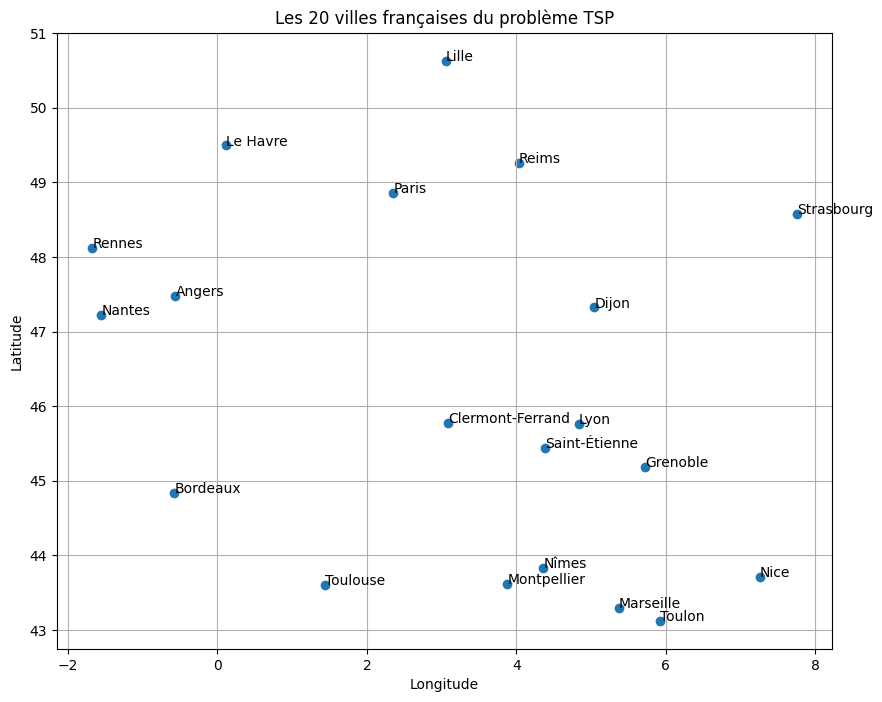

In [49]:
plt.figure(figsize=(10, 8))

plt.scatter(
    villes["Longitude"],
    villes["Latitude"]
)

for _, ville in villes.iterrows():

    plt.annotate(
        ville["Ville"],
        (ville["Longitude"], ville["Latitude"])
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Les 20 villes françaises du problème TSP")

plt.grid()

plt.show()

## 2. Résolution avec l'algorithme de Christofides

Le problème du voyageur de commerce étant NP-difficile, on ne peut pas tester les `(n-1)!` itinéraires possibles (plus de 10^17 pour nos 20 villes). L'algorithme de **Christofides** est une heuristique qui construit une solution *presque optimale* en temps raisonnable, avec une garantie théorique forte : sur un graphe métrique (où l'inégalité triangulaire est respectée, ce qui est le cas ici avec la distance de Haversine), la distance obtenue est au maximum **1.5 fois la distance optimale**.

### Les 6 étapes de l'algorithme

1. **Arbre couvrant de poids minimum (MST)** : on construit l'arbre qui relie toutes les villes avec la distance totale la plus faible possible, sans former de cycle.
2. **Sommets de degré impair** : dans cet arbre, certaines villes ont un nombre impair de routes qui y arrivent. Ce sont ces villes qui posent problème pour former un circuit (un circuit a besoin que chaque sommet ait un degré pair).
3. **Couplage parfait de poids minimum** : on relie les villes de degré impair entre elles deux par deux, en choisissant les paires qui minimisent la distance totale ajoutée.
4. **Fusion** : on combine l'arbre (étape 1) et le couplage (étape 3). Toutes les villes ont maintenant un degré pair.
5. **Circuit eulérien** : un graphe où tous les sommets ont un degré pair admet toujours un circuit qui emprunte chaque arête exactement une fois. On calcule ce circuit.
6. **Raccourcissement (shortcutting)** : le circuit eulérien peut repasser plusieurs fois par une même ville. On le transforme en circuit hamiltonien (chaque ville visitée une seule fois) en sautant directement les villes déjà visitées. Grâce à l'inégalité triangulaire, ce raccourci ne peut jamais rallonger le trajet.

### Pourquoi cet algorithme est pertinent pour Théobald

- Le graphe est **métrique** (distances géographiques réelles) : la garantie théorique de 1.5x l'optimum s'applique directement.
- L'algorithme est **déterministe** : à villes fixées, il donne toujours le même itinéraire, ce qui est rassurant pour un marchand qui veut planifier ses tournées de façon fiable.
- Il est **rapide** (complexité polynomiale), donc parfaitement adapté à une instance de 20 villes.


### Construction du graphe à partir de la matrice de distances

In [50]:
import networkx as nx

G = nx.Graph()

for i, ville in villes.iterrows():
    G.add_node(ville["Ville"], lat=ville["Latitude"], lon=ville["Longitude"])

for i in range(n):
    for j in range(i + 1, n):
        ville_i = villes.iloc[i]["Ville"]
        ville_j = villes.iloc[j]["Ville"]
        G.add_edge(ville_i, ville_j, weight=matrice_distances[i][j])

print(f"Graphe : {G.number_of_nodes()} sommets, {G.number_of_edges()} arêtes")

Graphe : 20 sommets, 190 arêtes


### Étape 1 : arbre couvrant de poids minimum (MST)

In [51]:
mst = nx.minimum_spanning_tree(G, weight="weight", algorithm="kruskal")

poids_mst = sum(d["weight"] for _, _, d in mst.edges(data=True))
print(f"MST : {mst.number_of_edges()} arêtes, poids total = {poids_mst:.1f} km")

MST : 19 arêtes, poids total = 2665.0 km


### Étape 2 : sommets de degré impair dans le MST

In [52]:
sommets_impairs = [sommet for sommet, degre in mst.degree() if degre % 2 == 1]

print(f"Sommets de degré impair ({len(sommets_impairs)}) : {sommets_impairs}")

Sommets de degré impair (12) : ['Lyon', 'Nice', 'Strasbourg', 'Bordeaux', 'Lille', 'Reims', 'Saint-Étienne', 'Grenoble', 'Dijon', 'Angers', 'Nîmes', 'Clermont-Ferrand']


### Étape 3 : couplage parfait de poids minimum

NetworkX ne propose qu'un couplage de poids **maximum** (`max_weight_matching`). On "inverse" donc les poids (poids_max - poids) pour transformer le problème en un problème de poids maximum équivalent, ce qui revient à minimiser la distance.

In [53]:
def couplage_poids_minimum(G, sommets_impairs):
    sous_graphe = nx.Graph()
    sous_graphe.add_nodes_from(sommets_impairs)

    poids_liste = []
    for i in range(len(sommets_impairs)):
        for j in range(i + 1, len(sommets_impairs)):
            u, v = sommets_impairs[i], sommets_impairs[j]
            w = G[u][v]["weight"]
            sous_graphe.add_edge(u, v, weight=w)
            poids_liste.append(w)

    poids_max = max(poids_liste) if poids_liste else 0

    # On inverse les poids pour transformer la minimisation en maximisation
    graphe_inverse = nx.Graph()
    for u, v, data in sous_graphe.edges(data=True):
        graphe_inverse.add_edge(u, v, weight=(poids_max - data["weight"]) + 1.0)

    couplage = nx.algorithms.matching.max_weight_matching(graphe_inverse, maxcardinality=True)
    return list(couplage)


couplage = couplage_poids_minimum(G, sommets_impairs)
print(f"Couplage de poids minimum : {couplage}")

Couplage de poids minimum : [('Nice', 'Nîmes'), ('Saint-Étienne', 'Clermont-Ferrand'), ('Lille', 'Reims'), ('Lyon', 'Grenoble'), ('Strasbourg', 'Dijon'), ('Bordeaux', 'Angers')]


### Étape 4 : fusion du MST et du couplage

On combine les arêtes du MST et celles du couplage dans un multigraphe. Tous les sommets ont désormais un degré pair, ce qui garantit l'existence d'un circuit eulérien.

In [54]:
multigraphe = nx.MultiGraph()
multigraphe.add_nodes_from(G.nodes())
multigraphe.add_edges_from(mst.edges(data=True))

for u, v in couplage:
    multigraphe.add_edge(u, v, weight=G[u][v]["weight"])

degres = dict(multigraphe.degree())
print("Tous les degrés sont-ils pairs ?", all(d % 2 == 0 for d in degres.values()))

Tous les degrés sont-ils pairs ? True


### Étape 5 : circuit eulérien

In [55]:
circuit_eulerien = list(nx.eulerian_circuit(multigraphe, source=villes["Ville"].iloc[0]))

print(f"Circuit eulérien : {len(circuit_eulerien)} arêtes")
print(circuit_eulerien)

Circuit eulérien : 25 arêtes
[('Paris', 'Le Havre'), ('Le Havre', 'Rennes'), ('Rennes', 'Nantes'), ('Nantes', 'Angers'), ('Angers', 'Bordeaux'), ('Bordeaux', 'Toulouse'), ('Toulouse', 'Montpellier'), ('Montpellier', 'Nîmes'), ('Nîmes', 'Nice'), ('Nice', 'Toulon'), ('Toulon', 'Marseille'), ('Marseille', 'Nîmes'), ('Nîmes', 'Saint-Étienne'), ('Saint-Étienne', 'Clermont-Ferrand'), ('Clermont-Ferrand', 'Saint-Étienne'), ('Saint-Étienne', 'Lyon'), ('Lyon', 'Grenoble'), ('Grenoble', 'Lyon'), ('Lyon', 'Dijon'), ('Dijon', 'Strasbourg'), ('Strasbourg', 'Dijon'), ('Dijon', 'Reims'), ('Reims', 'Lille'), ('Lille', 'Reims'), ('Reims', 'Paris')]


### Étape 6 : raccourcissement en circuit hamiltonien (shortcutting)

On parcourt le circuit eulérien et on ne garde que la première visite de chaque ville, ce qui donne l'itinéraire final de Théobald.

In [56]:
visites = set()
itineraire = []

for u, v in circuit_eulerien:
    if u not in visites:
        itineraire.append(u)
        visites.add(u)

# Sécurité : s'assurer que toutes les villes sont bien présentes
for ville in villes["Ville"]:
    if ville not in visites:
        itineraire.append(ville)
        visites.add(ville)

print(" -> ".join(itineraire + [itineraire[0]]))

Paris -> Le Havre -> Rennes -> Nantes -> Angers -> Bordeaux -> Toulouse -> Montpellier -> Nîmes -> Nice -> Toulon -> Marseille -> Saint-Étienne -> Clermont-Ferrand -> Lyon -> Grenoble -> Dijon -> Strasbourg -> Reims -> Lille -> Paris


### Distance totale de l'itinéraire

In [57]:
def distance_itineraire(matrice_df, itineraire):
    total = 0
    n = len(itineraire)
    for i in range(n):
        ville_a = itineraire[i]
        ville_b = itineraire[(i + 1) % n]
        total += matrice_df.loc[ville_a, ville_b]
    return total


distance_totale = distance_itineraire(matrice_df, itineraire)
print(f"Distance totale de l'itinéraire (Christofides) : {distance_totale:.1f} km")

Distance totale de l'itinéraire (Christofides) : 3445.6 km


### Affichage de l'itineraire sur la carte du marchand

On passe de matplotlib a **Folium** (bibliotheque Python autour de Leaflet.js) pour obtenir une vraie carte interactive : fond de carte reel (rues, relief, villes), zoom/deplacement a la souris, info-bulles au survol, et une ligne animee pour materialiser le trajet de Theobald. Rendu bien plus "pro" pour une presentation qu'un simple nuage de points.

> Installation si besoin : `pip install folium` (une seule fois).

In [58]:
%pip install folium --quiet

Note: you may need to restart the kernel to use updated packages.


In [59]:
import folium
from folium.plugins import AntPath

centre_lat = villes["Latitude"].mean()
centre_lon = villes["Longitude"].mean()

m = folium.Map(
    location=[centre_lat, centre_lon],
    zoom_start=6,
    tiles="CartoDB positron",
)

# --- Marqueurs numérotés selon l'ordre de visite ---
for ordre, ville in enumerate(itineraire, start=1):
    lat = G.nodes[ville]["lat"]
    lon = G.nodes[ville]["lon"]
    est_depart = (ville == itineraire[0])

    couleur = "#e8b923" if est_depart else "#1f3b57"
    texte = "★" if est_depart else str(ordre)

    folium.Marker(
        location=[lat, lon],
        tooltip=f"{ordre}. {ville}" if not est_depart else f"Départ : {ville}",
        icon=folium.DivIcon(html=f"""
            <div style="
                background-color:{couleur};
                color:white;
                border-radius:50%;
                width:28px;height:28px;
                display:flex;align-items:center;justify-content:center;
                font-size:12px;font-weight:bold;
                border:2px solid white;
                box-shadow:0 1px 4px rgba(0,0,0,0.4);
            ">{texte}</div>
        """),
    ).add_to(m)

# --- Itinéraire : ligne animée (pointillés qui "avancent") ---
boucle = itineraire + [itineraire[0]]
coords = [[G.nodes[v]["lat"], G.nodes[v]["lon"]] for v in boucle]

AntPath(
    coords,
    color="#c0392b",
    weight=3.5,
    delay=800,
    dash_array=[12, 20],
).add_to(m)

# --- Titre flottant ---
titre_html = f"""
<div style="
    position: fixed; top: 12px; left: 50%; transform: translateX(-50%);
    z-index: 9999; background-color: white; padding: 10px 20px;
    border-radius: 8px; box-shadow: 0 2px 8px rgba(0,0,0,0.25);
    font-family: sans-serif; text-align:center;
">
    <b style="font-size:15px; color:#1f3b57;">Itinéraire de Théobald — Algorithme de Christofides</b><br>
    <span style="font-size:12px; color:#555;">Distance totale : {distance_totale:.0f} km · {len(itineraire)} villes</span>
</div>
"""
m.get_root().html.add_child(folium.Element(titre_html))

m.fit_bounds(coords)

m

Sauvegarde en fichier HTML autonome (pratique pour l'integrer dans les diapositives ou l'ouvrir dans un navigateur) :

In [60]:
m.save("itineraire_theobald_christofides.html")

### Conclusion sur Christofides

L'algorithme de Christofides donne un itinéraire de **distance totale ≈ 3446 km** (à recalculer en exécutant ce notebook, le résultat étant déterministe pour ce jeu de 20 villes). 

Cette solution est garantie à moins de 1.5x la distance optimale, obtenue en quelques millisecondes seulement — un excellent compromis pour Théobald, qui a besoin d'un itinéraire fiable et rapide à calculer, sans avoir à explorer les `(n-1)!` chemins possibles.